# Intro

In [1]:
import os, sys
import platform
import numpy as np
import pickle 

In [2]:
from collections import defaultdict

In [3]:
from dcms.models import DCMModel, DECMModel, ADECMModel, DWCMModel

In [43]:
import matplotlib.pyplot as plt

In [63]:
from scipy.stats import spearmanr

## Load data

In [9]:
if platform.system() == 'Darwin':
    print('Air!')
    HOME = '/Users/fabio/Documents/Lavoro/PythonFiles/bowtie2_py310/bowtie2/'
elif platform.system() == 'Linux':
    print('Stella!')
    HOME = '/home/sarawalk/bowtie2_py39/bowtie2/'
else:
    raise RuntimeError(f"Unsupported OS: {platform.system()}")


Stella!


In [10]:
sys.path.insert(0, HOME)

In [11]:
DATA_FOLDER=HOME+'dati_elezioni/'

### Original data

In [12]:
files=os.listdir(DATA_FOLDER)
files.sort()

In [13]:
files

['crisi_dicos.csv',
 'crisi_weighted_edgelist.csv',
 'ita_elections_dicos.csv',
 'ita_elections_weighted_edgelist.csv',
 'quirinale_dicos.csv',
 'quirinale_weighted_edgelist.csv']

In [14]:
l_dataset=len(files)//2

### Processed data

In [15]:
TEST_FOLDER=HOME+'tests/'

In [18]:
test_files=[file for file in os.listdir(TEST_FOLDER) if file.endswith('_adecm.pkl')]
test_files.sort()
test_files

['crisi_dico0_adecm.pkl',
 'crisi_dico1_adecm.pkl',
 'crisi_dico2_adecm.pkl',
 'crisi_dico3_adecm.pkl',
 'crisi_dico4_adecm.pkl',
 'ita_elections_dico2_adecm.pkl',
 'ita_elections_dico3_adecm.pkl',
 'ita_elections_dico4_adecm.pkl',
 'ita_elections_dico5_adecm.pkl',
 'ita_elections_dico6_adecm.pkl',
 'quirinale_dico0_adecm.pkl',
 'quirinale_dico1_adecm.pkl',
 'quirinale_dico2_adecm.pkl',
 'quirinale_dico3_adecm.pkl',
 'quirinale_dico4_adecm.pkl',
 'quirinale_dico5_adecm.pkl',
 'quirinale_dico6_adecm.pkl']

### Looking for some patterns in the set of solved models

In [41]:
solved=0
models=[]
for file in test_files:
    with open(TEST_FOLDER+file, 'rb') as f:
        model=pickle.load(f)
    models.append(model)
    print(f'{file:30} N={model.N:6,d}, weights={model.sol_weights.converged:}')
    if model.sol_weights.converged:
        solved+=1
print(f'{solved}/{len(test_files)} solved ({solved/len(test_files)*100:.2f}%)')

crisi_dico0_adecm.pkl          N=58,832, weights=False
crisi_dico1_adecm.pkl          N=31,874, weights=False
crisi_dico2_adecm.pkl          N=15,168, weights=True
crisi_dico3_adecm.pkl          N= 1,304, weights=False
crisi_dico4_adecm.pkl          N= 3,637, weights=True
ita_elections_dico2_adecm.pkl  N=20,914, weights=True
ita_elections_dico3_adecm.pkl  N=28,156, weights=True
ita_elections_dico4_adecm.pkl  N= 9,010, weights=True
ita_elections_dico5_adecm.pkl  N=   373, weights=False
ita_elections_dico6_adecm.pkl  N=   337, weights=False
quirinale_dico0_adecm.pkl      N=33,244, weights=True
quirinale_dico1_adecm.pkl      N=11,045, weights=False
quirinale_dico2_adecm.pkl      N=18,704, weights=True
quirinale_dico3_adecm.pkl      N= 3,000, weights=True
quirinale_dico4_adecm.pkl      N=22,754, weights=False
quirinale_dico5_adecm.pkl      N=27,746, weights=False
quirinale_dico6_adecm.pkl      N=   232, weights=False
8/17 solved (47.06%)


In [42]:
res_final=[model.sol_weights.residuals[-1] for model in models]
Ns=[model.N for model in models]

In [48]:
color_dict={'crisi': 'navy', 'ita': 'darkcyan', 'quirinale': 'orange'}

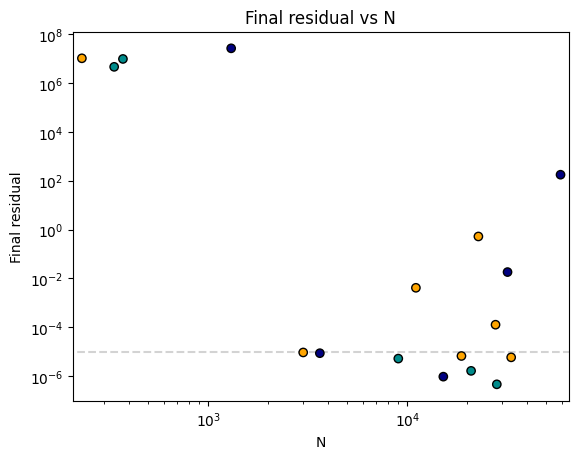

In [61]:
plt.scatter(Ns, res_final, color=[color_dict[file.split('_')[0]] for file in test_files], edgecolor='black', zorder=2)
plt.hlines([1e-5], 0.5*min(Ns), 1.5*max(Ns), linestyles='--', colors='lightgray', zorder=1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Final residual')
plt.title('Final residual vs N')
plt.xlim(0.9*min(Ns), 1.1*max(Ns))
plt.show()

Still unsatisfactory as   
1. some communities were exclude _a priori_ as they were too big and 
2. adecm does not converge for all community of at least a dataset. 

Remarkably, it seems that only networks in a limited interval of N converge and not even always. 

In [66]:
spearman_in=[spearmanr(model.k_in, model.s_in) for model in models]
spearman_out=[spearmanr(model.k_out, model.s_out) for model in models]

In [73]:
statistics_in=[res.statistic for res in spearman_in]
statistics_out=[res.statistic for res in spearman_out]
p_in=[res.pvalue for res in spearman_in]
p_out=[res.pvalue for res in spearman_out]
alpha=0.05
significant_in=[p<alpha/len(p_in) for p in p_in]
significant_out=[p<alpha/len(p_out) for p in p_out]

In [ ]:
max(p_in), max(p_out) # all entries are statistically validated

(np.float64(2.7854416023046003e-80), np.float64(1.4752113043071724e-308))

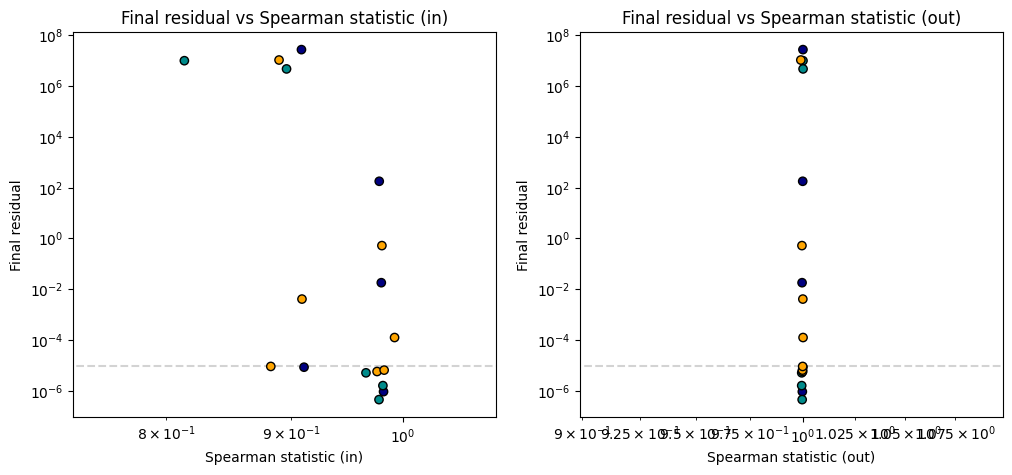

In [87]:
fig, axs=plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(statistics_in, res_final, color=[color_dict[file.split('_')[0]] for file in test_files], zorder=2, marker='o', edgecolor='black')
axs[0].hlines([1e-5], 0.5*min(statistics_in), 1.5*max(statistics_in), linestyles='--', colors='lightgray', zorder=1)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel('Spearman statistic (in)')
axs[0].set_ylabel('Final residual')
axs[0].set_title('Final residual vs Spearman statistic (in)')
axs[0].set_xlim(0.9*min(statistics_in), 1.1*max(statistics_in))

axs[1].scatter(statistics_out, res_final, color=[color_dict[file.split('_')[0]] for file in test_files], zorder=2, marker='o', edgecolor='black')
axs[1].hlines([1e-5], 0.5*min(statistics_out), 1.5*max(statistics_out), linestyles='--', colors='lightgray', zorder=1)
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('Spearman statistic (out)')
axs[1].set_ylabel('Final residual')
axs[1].set_title('Final residual vs Spearman statistic (out)')
axs[1].set_xlim(0.9*min(statistics_out), 1.1*max(statistics_out))

plt.show()

In [88]:
statistics_out

[np.float64(0.9998212592552199),
 np.float64(0.9995185414992381),
 np.float64(0.9996472987750475),
 np.float64(0.9999351001645906),
 np.float64(0.9999167899833881),
 np.float64(0.9993474675958776),
 np.float64(0.9995657917029245),
 np.float64(0.999354634043174),
 np.float64(0.9999576270526884),
 np.float64(0.9999955341556265),
 np.float64(0.999810781515104),
 np.float64(0.9998861106529683),
 np.float64(0.9997033844958405),
 np.float64(0.9997988435811836),
 np.float64(0.9994596072484426),
 np.float64(0.9999884036183305),
 np.float64(0.9989197277770694)]

In [89]:
statistics_in

[np.float64(0.9780033458226581),
 np.float64(0.9799045886630656),
 np.float64(0.9819796399460173),
 np.float64(0.9087457429376457),
 np.float64(0.9109544619075464),
 np.float64(0.9813883249123349),
 np.float64(0.9777865472381307),
 np.float64(0.9658262674528844),
 np.float64(0.8136266529892235),
 np.float64(0.8960411864100172),
 np.float64(0.9759964534988202),
 np.float64(0.9091917381693236),
 np.float64(0.9825425563139273),
 np.float64(0.882814184301464),
 np.float64(0.9804617970018126),
 np.float64(0.9922555952203252),
 np.float64(0.8897171896610743)]